In [1]:
# ==========================================================
# DevelopersHub Corporation
# AI/ML Engineering Advanced Internship
# Task 2
# End-to-End Machine Learning Pipeline
# ==========================================================

# Install required package for saving the trained pipeline
!pip install -q joblib

In [2]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn modules
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

import joblib

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# ==========================================================
# Project Introduction
# ==========================================================

print("""
END-TO-END MACHINE LEARNING PIPELINE

Objective:
Build a reusable machine learning pipeline
to predict customer churn using the
IBM Telco Customer Churn Dataset.

Models Used:
1. Logistic Regression
2. Random Forest

Pipeline Components:
✓ Missing Value Handling
✓ Feature Scaling
✓ One-Hot Encoding
✓ Hyperparameter Tuning
✓ Model Evaluation
✓ Pipeline Export using Joblib
""")


END-TO-END MACHINE LEARNING PIPELINE

Objective:
Build a reusable machine learning pipeline
to predict customer churn using the
IBM Telco Customer Churn Dataset.

Models Used:
1. Logistic Regression
2. Random Forest

Pipeline Components:
✓ Missing Value Handling
✓ Feature Scaling
✓ One-Hot Encoding
✓ Hyperparameter Tuning
✓ Model Evaluation
✓ Pipeline Export using Joblib



In [5]:
# ==========================================================
# Load Dataset
# ==========================================================

from google.colab import files
import pandas as pd

# Upload CSV file
uploaded = files.upload()

# Get uploaded filename automatically
filename = list(uploaded.keys())[0]

# Read dataset
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Filename:", filename)

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataset loaded successfully!
Filename: WA_Fn-UseC_-Telco-Customer-Churn.csv


In [6]:
# ==========================================================
# Dataset Overview
# ==========================================================

print("Dataset Shape:")
print(df.shape)

print("\nFirst Five Rows:")

display(df.head())

print("\nColumn Names:")

print(df.columns.tolist())

Dataset Shape:
(7043, 21)

First Five Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [7]:
# ==========================================================
# Dataset Information
# ==========================================================

print("Dataset Information:\n")

df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

In [8]:
# ==========================================================
# Summary Statistics
# ==========================================================

display(df.describe(include='all'))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [9]:
# ==========================================================
# Missing Values
# ==========================================================

print("Missing Values in Each Column\n")

display(df.isnull().sum())

Missing Values in Each Column



,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
# ==========================================================
# Data Cleaning
# ==========================================================

# Remove customerID because it is not useful
df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric
# Invalid values become NaN

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Convert target column into numerical values

df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

print("Data Cleaning Completed!")

Data Cleaning Completed!


In [11]:
# ==========================================================
# Verify Missing Values
# ==========================================================

print(df.isnull().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [12]:
# ==========================================================
# Separate Features and Target
# ==========================================================

X = df.drop("Churn", axis=1)

y = df["Churn"]

print("Feature Matrix Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Matrix Shape : (7043, 19)
Target Shape : (7043,)


In [13]:
# ==========================================================
# Identify Feature Types
# ==========================================================

numeric_features = X.select_dtypes(
    include=["int64","float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Numerical Features")

print(numeric_features)

print()

print("Categorical Features")

print(categorical_features)

Numerical Features
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

Categorical Features
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [14]:
# ==========================================================
# Numerical Preprocessing Pipeline
# ==========================================================

numeric_transformer = Pipeline(

    steps=[

        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        (
            "scaler",
            StandardScaler()
        )

    ]

)

In [15]:
# ==========================================================
# Categorical Preprocessing Pipeline
# ==========================================================

categorical_transformer = Pipeline(

    steps=[

        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),

        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )

    ]

)

In [16]:
# ==========================================================
# Column Transformer
# ==========================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            numeric_transformer,
            numeric_features
        ),

        (
            "cat",
            categorical_transformer,
            categorical_features
        )

    ]

)

print("Preprocessing Pipeline Created Successfully!")

Preprocessing Pipeline Created Successfully!


In [17]:
# ==========================================================
# Split Dataset
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Samples :", len(X_train))

print("Testing Samples :", len(X_test))

Training Samples : 5634
Testing Samples : 1409


In [18]:
# ==========================================================
# Logistic Regression Pipeline
# ==========================================================

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

print("Logistic Regression Pipeline Created Successfully!")

Logistic Regression Pipeline Created Successfully!


In [19]:
# ==========================================================
# Train Logistic Regression Model
# ==========================================================

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression Training Completed!")

Logistic Regression Training Completed!


In [20]:
# ==========================================================
# Logistic Regression Prediction
# ==========================================================

logistic_predictions = logistic_pipeline.predict(X_test)

print("Prediction Completed!")

Prediction Completed!


In [21]:
# ==========================================================
# Logistic Regression Evaluation
# ==========================================================

print("Logistic Regression Results\n")

print("Accuracy :", accuracy_score(y_test, logistic_predictions))
print("Precision:", precision_score(y_test, logistic_predictions))
print("Recall   :", recall_score(y_test, logistic_predictions))
print("F1 Score :", f1_score(y_test, logistic_predictions))

print("\nClassification Report\n")

print(classification_report(y_test, logistic_predictions))

Logistic Regression Results

Accuracy : 0.8055358410220014
Precision: 0.6572327044025157
Recall   : 0.5588235294117647
F1 Score : 0.6040462427745664

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [22]:
# ==========================================================
# Random Forest Pipeline
# ==========================================================

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)

print("Random Forest Pipeline Created Successfully!")

Random Forest Pipeline Created Successfully!


In [23]:
# ==========================================================
# Hyperparameter Grid
# ==========================================================

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 20, None],
    "classifier__min_samples_split": [2, 5]
}

print("GridSearch Parameters Ready!")

GridSearch Parameters Ready!


In [24]:
# ==========================================================
# Hyperparameter Tuning
# ==========================================================

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("GridSearch Completed Successfully!")

GridSearch Completed Successfully!


In [25]:
# ==========================================================
# Best Parameters
# ==========================================================

print("Best Parameters\n")

print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy")

print(grid_search.best_score_)

Best Parameters

{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Best Cross Validation Accuracy
0.8036918707845225


In [26]:
# ==========================================================
# Best Model Prediction
# ==========================================================

best_model = grid_search.best_estimator_

rf_predictions = best_model.predict(X_test)

print("Prediction Completed!")

Prediction Completed!


In [27]:
# ==========================================================
# Random Forest Evaluation
# ==========================================================

accuracy = accuracy_score(y_test, rf_predictions)
precision = precision_score(y_test, rf_predictions)
recall = recall_score(y_test, rf_predictions)
f1 = f1_score(y_test, rf_predictions)

print("Random Forest Results\n")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report\n")

print(classification_report(y_test, rf_predictions))

Random Forest Results

Accuracy : 0.7998580553584103
Precision: 0.6564625850340136
Recall   : 0.516042780748663
F1 Score : 0.5778443113772455

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [28]:
# ==========================================================
# Model Comparison
# ==========================================================

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, rf_predictions)
    ],
    "Precision": [
        precision_score(y_test, logistic_predictions),
        precision_score(y_test, rf_predictions)
    ],
    "Recall": [
        recall_score(y_test, logistic_predictions),
        recall_score(y_test, rf_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, logistic_predictions),
        f1_score(y_test, rf_predictions)
    ]
})

display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046
1,Random Forest,0.799858,0.656463,0.516043,0.577844


<Figure size 600x600 with 0 Axes>

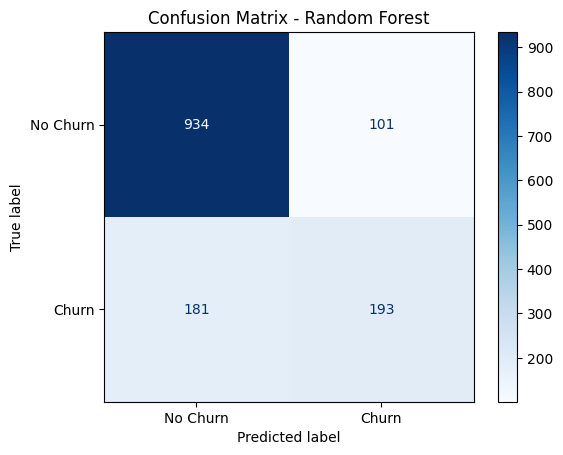

In [29]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, rf_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [30]:
# ==========================================================
# Get Feature Names After Encoding
# ==========================================================

# Numerical feature names
numeric_names = list(numeric_features)

# One-Hot Encoded categorical names
encoded_names = best_model.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .named_steps["encoder"] \
    .get_feature_names_out(categorical_features)

feature_names = numeric_names + list(encoded_names)

print("Total Features:", len(feature_names))

Total Features: 45


In [31]:
# ==========================================================
# Feature Importance
# ==========================================================

importances = best_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(importance_df.head(10))

,Feature,Importance
1,tenure,0.147687
3,TotalCharges,0.121887
36,Contract_Month-to-month,0.097549
2,MonthlyCharges,0.083842
18,OnlineSecurity_No,0.057482
27,TechSupport_No,0.047131
16,InternetService_Fiber optic,0.046421
43,PaymentMethod_Electronic check,0.039788
38,Contract_Two year,0.028294
15,InternetService_DSL,0.020942


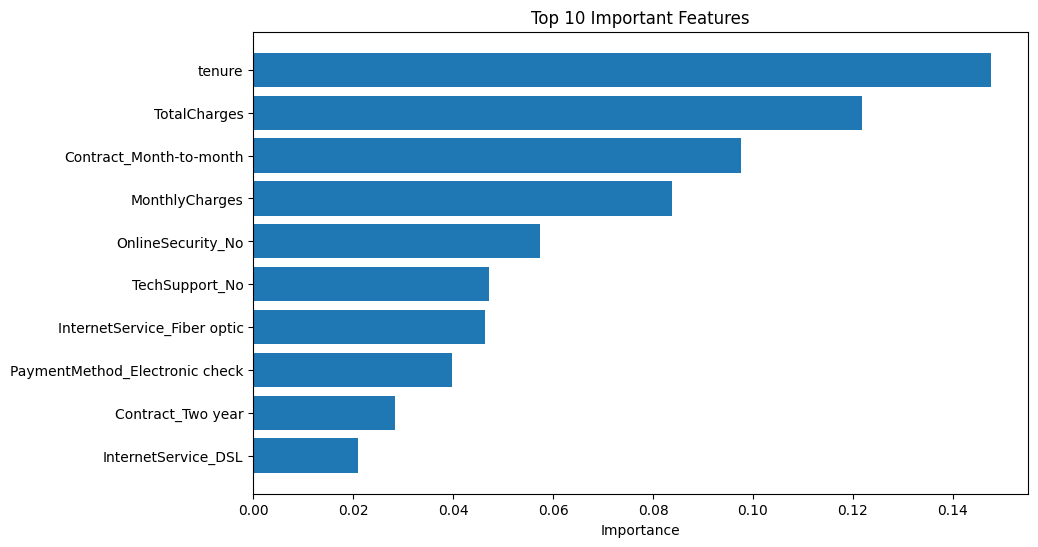

In [32]:
# ==========================================================
# Plot Top 10 Important Features
# ==========================================================

top10 = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Top 10 Important Features")

plt.show()

In [33]:
# ==========================================================
# Save Trained Pipeline
# ==========================================================

joblib.dump(
    best_model,
    "churn_pipeline.pkl"
)

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [34]:
# ==========================================================
# Final Project Summary
# ==========================================================

print("""
====================================================

END-TO-END MACHINE LEARNING PIPELINE

Project Completed Successfully

====================================================

Dataset:
IBM Telco Customer Churn

Models Implemented:
✓ Logistic Regression
✓ Random Forest

Preprocessing:
✓ Missing Value Handling
✓ One-Hot Encoding
✓ Standard Scaling

Hyperparameter Optimization:
✓ GridSearchCV

Evaluation Metrics:
✓ Accuracy
✓ Precision
✓ Recall
✓ F1 Score

Best Parameters:
Maximum Depth = 10
Minimum Samples Split = 5
Number of Trees = 200

Pipeline Exported Successfully
(File: churn_pipeline.pkl)

====================================================
""")



END-TO-END MACHINE LEARNING PIPELINE

Project Completed Successfully


Dataset:
IBM Telco Customer Churn

Models Implemented:
✓ Logistic Regression
✓ Random Forest

Preprocessing:
✓ Missing Value Handling
✓ One-Hot Encoding
✓ Standard Scaling

Hyperparameter Optimization:
✓ GridSearchCV

Evaluation Metrics:
✓ Accuracy
✓ Precision
✓ Recall
✓ F1 Score

Best Parameters:
Maximum Depth = 10
Minimum Samples Split = 5
Number of Trees = 200

Pipeline Exported Successfully
(File: churn_pipeline.pkl)




In [35]:
# ==========================================================
# Final Evaluation Table
# ==========================================================

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

display(results)

,Metric,Value
0,Accuracy,0.799858
1,Precision,0.656463
2,Recall,0.516043
3,F1 Score,0.577844


In [36]:
# ==========================================================
# Final Model Comparison
# ==========================================================

log_accuracy = accuracy_score(y_test, logistic_predictions)
log_precision = precision_score(y_test, logistic_predictions)
log_recall = recall_score(y_test, logistic_predictions)
log_f1 = f1_score(y_test, logistic_predictions)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [log_accuracy, accuracy],
    "Precision": [log_precision, precision],
    "Recall": [log_recall, recall],
    "F1 Score": [log_f1, f1]
})

print("Model Performance Comparison\n")
display(comparison)

Model Performance Comparison



,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046
1,Random Forest,0.799858,0.656463,0.516043,0.577844
